# Sprint 3 — Final Reusable Outcome-Prediction Pipeline

This notebook demonstrates the final end-to-end implementation of the project.

The actual pipeline logic is implemented in reusable Python modules:

- `src/pipeline/training_pipeline.py`
- `src/pipeline/evaluation_pipeline.py`

The notebook only configures, runs, and presents the pipeline. It does not duplicate data preparation, model training, evaluation, plotting, or SHAP logic.

The pipeline performs:

1. event-log loading;
2. final-activity outcome construction;
3. temporal train/validation/test splitting;
4. prefix generation after splitting;
5. aligned feature encoding;
6. leakage-related feature removal;
7. training of a majority baseline, Logistic Regression, and Random Forest;
8. validation-based Random Forest selection;
9. final test-set evaluation;
10. prediction export, plots, and SHAP explanations.


## 1. Project setup

The following cell locates the repository root. It works when the notebook is started either from the repository root or from the `notebooks/` directory.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

current_directory = Path.cwd().resolve()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/so/Desktop/explainable-process-prediction


## 2. Import the reusable pipelines

Only the public pipeline functions are imported here. All implementation details remain inside `src/`.


In [2]:
from src.pipeline import (
    run_evaluation_pipeline,
    run_training_pipeline,
)

/Users/so/Desktop/explainable-process-prediction/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Configuration

The final outcome is based on the final lifecycle transition of each original case:

- **positive outcome (`1`)**: the case ends in `Closed` or `Resolved`;
- **negative outcome (`0`)**: the case ends in another final transition.

The original cases are split temporally before prefixes are generated. This prevents prefixes from one original case from appearing in multiple data splits.


In [3]:
data_path = (
    project_root
    / "data"
    / "raw"
    / "BPI_Challenge_2013_incidents"
    / "BPI_Challenge_2013_incidents.xes"
)

output_dir = project_root / "outputs"

positive_final_activities = ["Closed", "Resolved"]
minimum_prefix_length = 1

print(f"Data path: {data_path}")
print(f"Output directory: {output_dir}")
print(f"Dataset exists: {data_path.exists()}")

Data path: /Users/so/Desktop/explainable-process-prediction/data/raw/BPI_Challenge_2013_incidents/BPI_Challenge_2013_incidents.xes
Output directory: /Users/so/Desktop/explainable-process-prediction/outputs
Dataset exists: True


## 4. Run the training pipeline

The training pipeline performs all steps from raw event-log loading to fitted models and validation results.

Its returned `TrainingPipelineResult` contains the trained models, aligned feature matrices, labels, case IDs, selected Random Forest parameters, validation tables, and dataset metadata.


In [4]:
training_result = run_training_pipeline(
    event_log_path=data_path,
    positive_final_activities=positive_final_activities,
    min_prefix=minimum_prefix_length,
    random_forest_scoring="f1",
)

print("Training pipeline completed.")

/Users/so/Desktop/explainable-process-prediction/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
parsing log, completed traces :: 100%|██████████| 7554/7554 [00:01<00:00, 6938.86it/s]


      org:group resource country organization country org:resource  \
0           V30           France                   fr     Frederic   
1           V30           France                   fr     Frederic   
2        V5 3rd           France                   fr     Frederic   
3        V5 3rd           France                   fr  Anne Claire   
4           V30           France                   fr  Anne Claire   
...         ...              ...                  ...          ...   
65528        C9           Brazil                   br      Lierson   
65529        C9           Brazil                   br      Lierson   
65530        C9           Brazil                   br      Lierson   
65531        C9           Brazil                   br      Lierson   
65532       N36              USA                   us         Matt   

      organization involved concept:name  product lifecycle:transition  \
0               Org line A2     Accepted  PROD582          In Progress   
1          

/Users/so/Desktop/explainable-process-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training pipeline completed.


## 5. Dataset and split summary

Each row in the encoded datasets represents a prefix of an original process case. Prefixes are generated separately inside the training, validation, and test splits.


In [5]:
dataset_summary = (
    pd.Series(training_result.dataset_summary, name="value")
    .rename_axis("property")
    .reset_index()
)

dataset_summary["property"] = (
    dataset_summary["property"]
    .str.replace("_", " ", regex=False)
    .str.capitalize()
)

dataset_summary

,property,value
0,Events,65533
1,Original cases,7554
2,Activities,4
3,Positive original cases,5663
4,Negative original cases,1891
5,Train original cases,5287
6,Validation original cases,1133
7,Test original cases,1134
8,Train prefixes,46644
9,Validation prefixes,5894


In [6]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "prefix_rows": [
            training_result.X_train.shape[0],
            training_result.X_validation.shape[0],
            training_result.X_test.shape[0],
        ],
        "features": [
            training_result.X_train.shape[1],
            training_result.X_validation.shape[1],
            training_result.X_test.shape[1],
        ],
        "positive_prefixes": [
            int((training_result.y_train == 1).sum()),
            int((training_result.y_validation == 1).sum()),
            int((training_result.y_test == 1).sum()),
        ],
        "negative_prefixes": [
            int((training_result.y_train == 0).sum()),
            int((training_result.y_validation == 0).sum()),
            int((training_result.y_test == 0).sum()),
        ],
    }
)

split_summary

,split,prefix_rows,features,positive_prefixes,negative_prefixes
0,train,46644,230,44331,2313
1,validation,5894,230,5047,847
2,test,5441,230,4523,918


## 6. Feature consistency and removed features

The training split defines the feature space. Validation and test data are aligned to exactly the same columns.

Features matching configured leakage-related keywords are removed consistently from all splits before model training.


In [7]:
assert (
    training_result.X_train.shape[1]
    == training_result.X_validation.shape[1]
    == training_result.X_test.shape[1]
    == len(training_result.feature_columns)
)

assert training_result.X_train.shape[0] == len(training_result.y_train)
assert training_result.X_validation.shape[0] == len(training_result.y_validation)
assert training_result.X_test.shape[0] == len(training_result.y_test)
assert training_result.X_test.shape[0] == len(training_result.case_ids_test)

print("Feature matrices, labels, and case IDs are aligned.")
print(f"Final number of features: {len(training_result.feature_columns)}")
print("Removed feature columns:")
training_result.removed_feature_columns

Feature matrices, labels, and case IDs are aligned.
Final number of features: 230
Removed feature columns:


['relative_age_sum',
 'relative_age_mean',
 'relative_age_min',
 'relative_age_max',
 'relative_age_std',
 'relative_age_count']

## 7. Random Forest model selection

Several Random Forest configurations are compared on the validation set. The configuration with the best validation F1 score is selected as the final black-box model.


In [8]:
print("Selected parameters:")
training_result.best_random_forest_parameters

Selected parameters:


{'n_estimators': 100, 'max_depth': 10}

In [9]:
training_result.random_forest_validation_results

,accuracy,f1,precision,recall,roc_auc,model,params
0,0.791822,0.861840,0.998174,0.758272,0.931521,"Random Forest {'n_estimators': 100, 'max_depth...","{'n_estimators': 100, 'max_depth': 5}"
1,0.807262,0.873412,0.997963,0.776501,0.937743,"Random Forest {'n_estimators': 100, 'max_depth...","{'n_estimators': 100, 'max_depth': 10}"
2,0.791313,0.861393,0.998693,0.757282,0.932639,"Random Forest {'n_estimators': 200, 'max_depth...","{'n_estimators': 200, 'max_depth': 5}"


## 8. Validation-set model comparison

The majority baseline is included as a trivial reference. Logistic Regression is the interpretable model, and Random Forest is the more complex model used for SHAP explanations.


In [10]:
training_result.validation_comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Majority baseline,0.856295,0.856295,1.000000,0.922585,0.500000
1,Logistic Regression,0.637258,0.996925,0.578165,0.731879,0.864023
2,Random Forest,0.807262,0.997963,0.776501,0.873412,0.937743


## 9. Run the evaluation pipeline

The evaluation pipeline uses the already trained models and the held-out test data. It creates:

- final test metrics;
- structured prediction outputs;
- model comparison and ROC plots;
- a Random Forest confusion matrix;
- global SHAP explanations;
- local SHAP explanations for representative test prefixes.


In [11]:
evaluation_result = run_evaluation_pipeline(
    training_result=training_result,
    output_dir=output_dir,
    generate_shap=True,
    shap_max_samples=300,
    shap_top_n=15,
    local_shap_max_display=10,
)

print("Evaluation pipeline completed.")

Evaluation pipeline completed.


## 10. Final test-set results

The held-out test set is used only after model selection. The table reports accuracy, precision, recall, F1, ROC AUC, and Precision-Recall AUC for all three models.


In [12]:
test_comparison = evaluation_result.test_comparison.copy()
test_comparison

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Majority baseline,0.831281,0.831281,1.000000,0.907868,0.500000,0.831281
1,Logistic Regression,0.618269,0.993145,0.544550,0.703413,0.835523,0.966182
2,Random Forest,0.802426,0.994266,0.766748,0.865810,0.929396,0.985848


In [13]:
metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
]

best_models = {
    metric: test_comparison.loc[
        test_comparison[metric].idxmax(),
        "model",
    ]
    for metric in metric_columns
    if test_comparison[metric].notna().any()
}

pd.Series(best_models, name="best model").rename_axis("metric").reset_index()

,metric,best model
0,accuracy,Majority baseline
1,precision,Random Forest
2,recall,Majority baseline
3,f1,Majority baseline
4,roc_auc,Random Forest
5,pr_auc,Random Forest


## 11. Structured prediction output

The prediction table contains the real prefix case IDs, true labels, predicted labels, probabilities, model metadata, split name, classification threshold, and sprint identifier.


In [14]:
evaluation_result.predictions.head(10)

,case_id,y_true,prediction,probability,model,model_type,dataset_split,threshold,sprint
0,1-738190601_prefix_1,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
1,1-738190601_prefix_2,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
2,1-738190601_prefix_3,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
3,1-738190601_prefix_4,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
4,1-738190601_prefix_5,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
5,1-738190601_prefix_6,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
6,1-738190601_prefix_7,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
7,1-738190601_prefix_8,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
8,1-738190621_prefix_1,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3
9,1-738190621_prefix_2,1,1,1.0,Majority baseline,baseline,test,0.5,sprint3


In [15]:
prediction_counts = (
    evaluation_result.predictions
    .groupby("model")
    .agg(
        prediction_rows=("case_id", "size"),
        unique_prefixes=("case_id", "nunique"),
        mean_probability=("probability", "mean"),
    )
    .reset_index()
)

prediction_counts

,model,prediction_rows,unique_prefixes,mean_probability
0,Logistic Regression,5441,5441,0.540684
1,Majority baseline,5441,5441,1.000000
2,Random Forest,5441,5441,0.717475


## 12. Evaluation plots

All figures are generated by the reusable evaluation pipeline and saved under `outputs/figures/`.


### Model Comparison

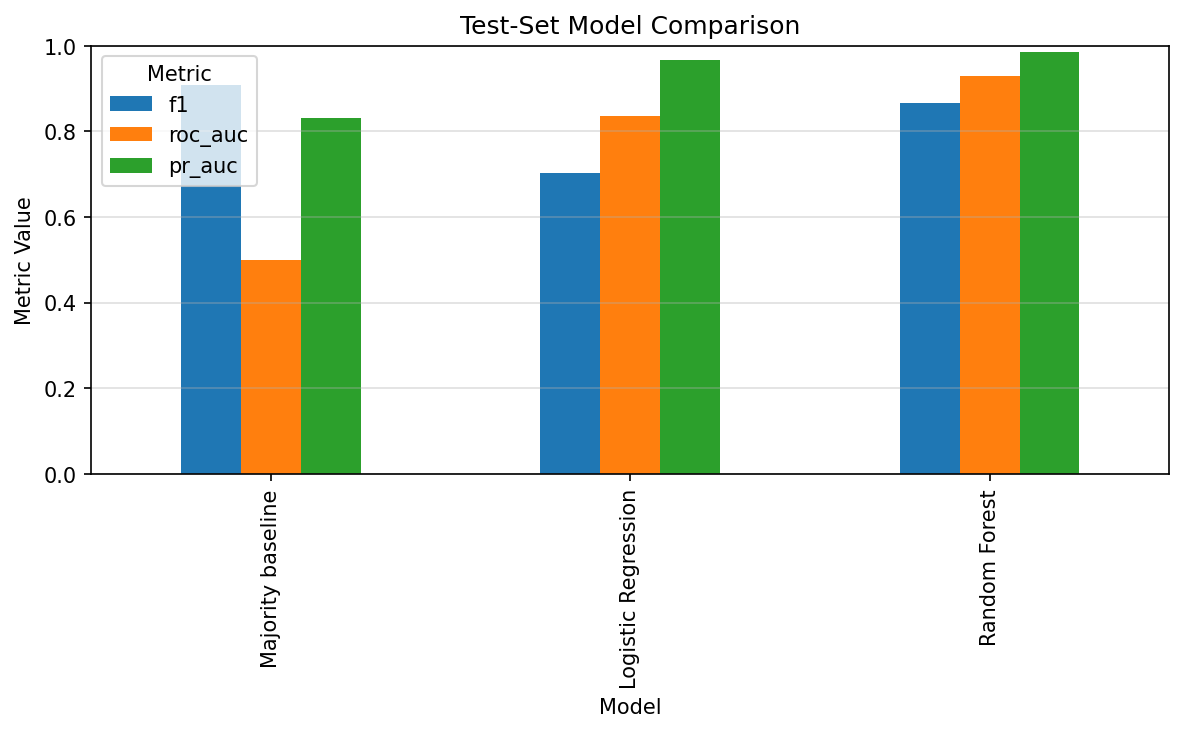

### Roc Curves

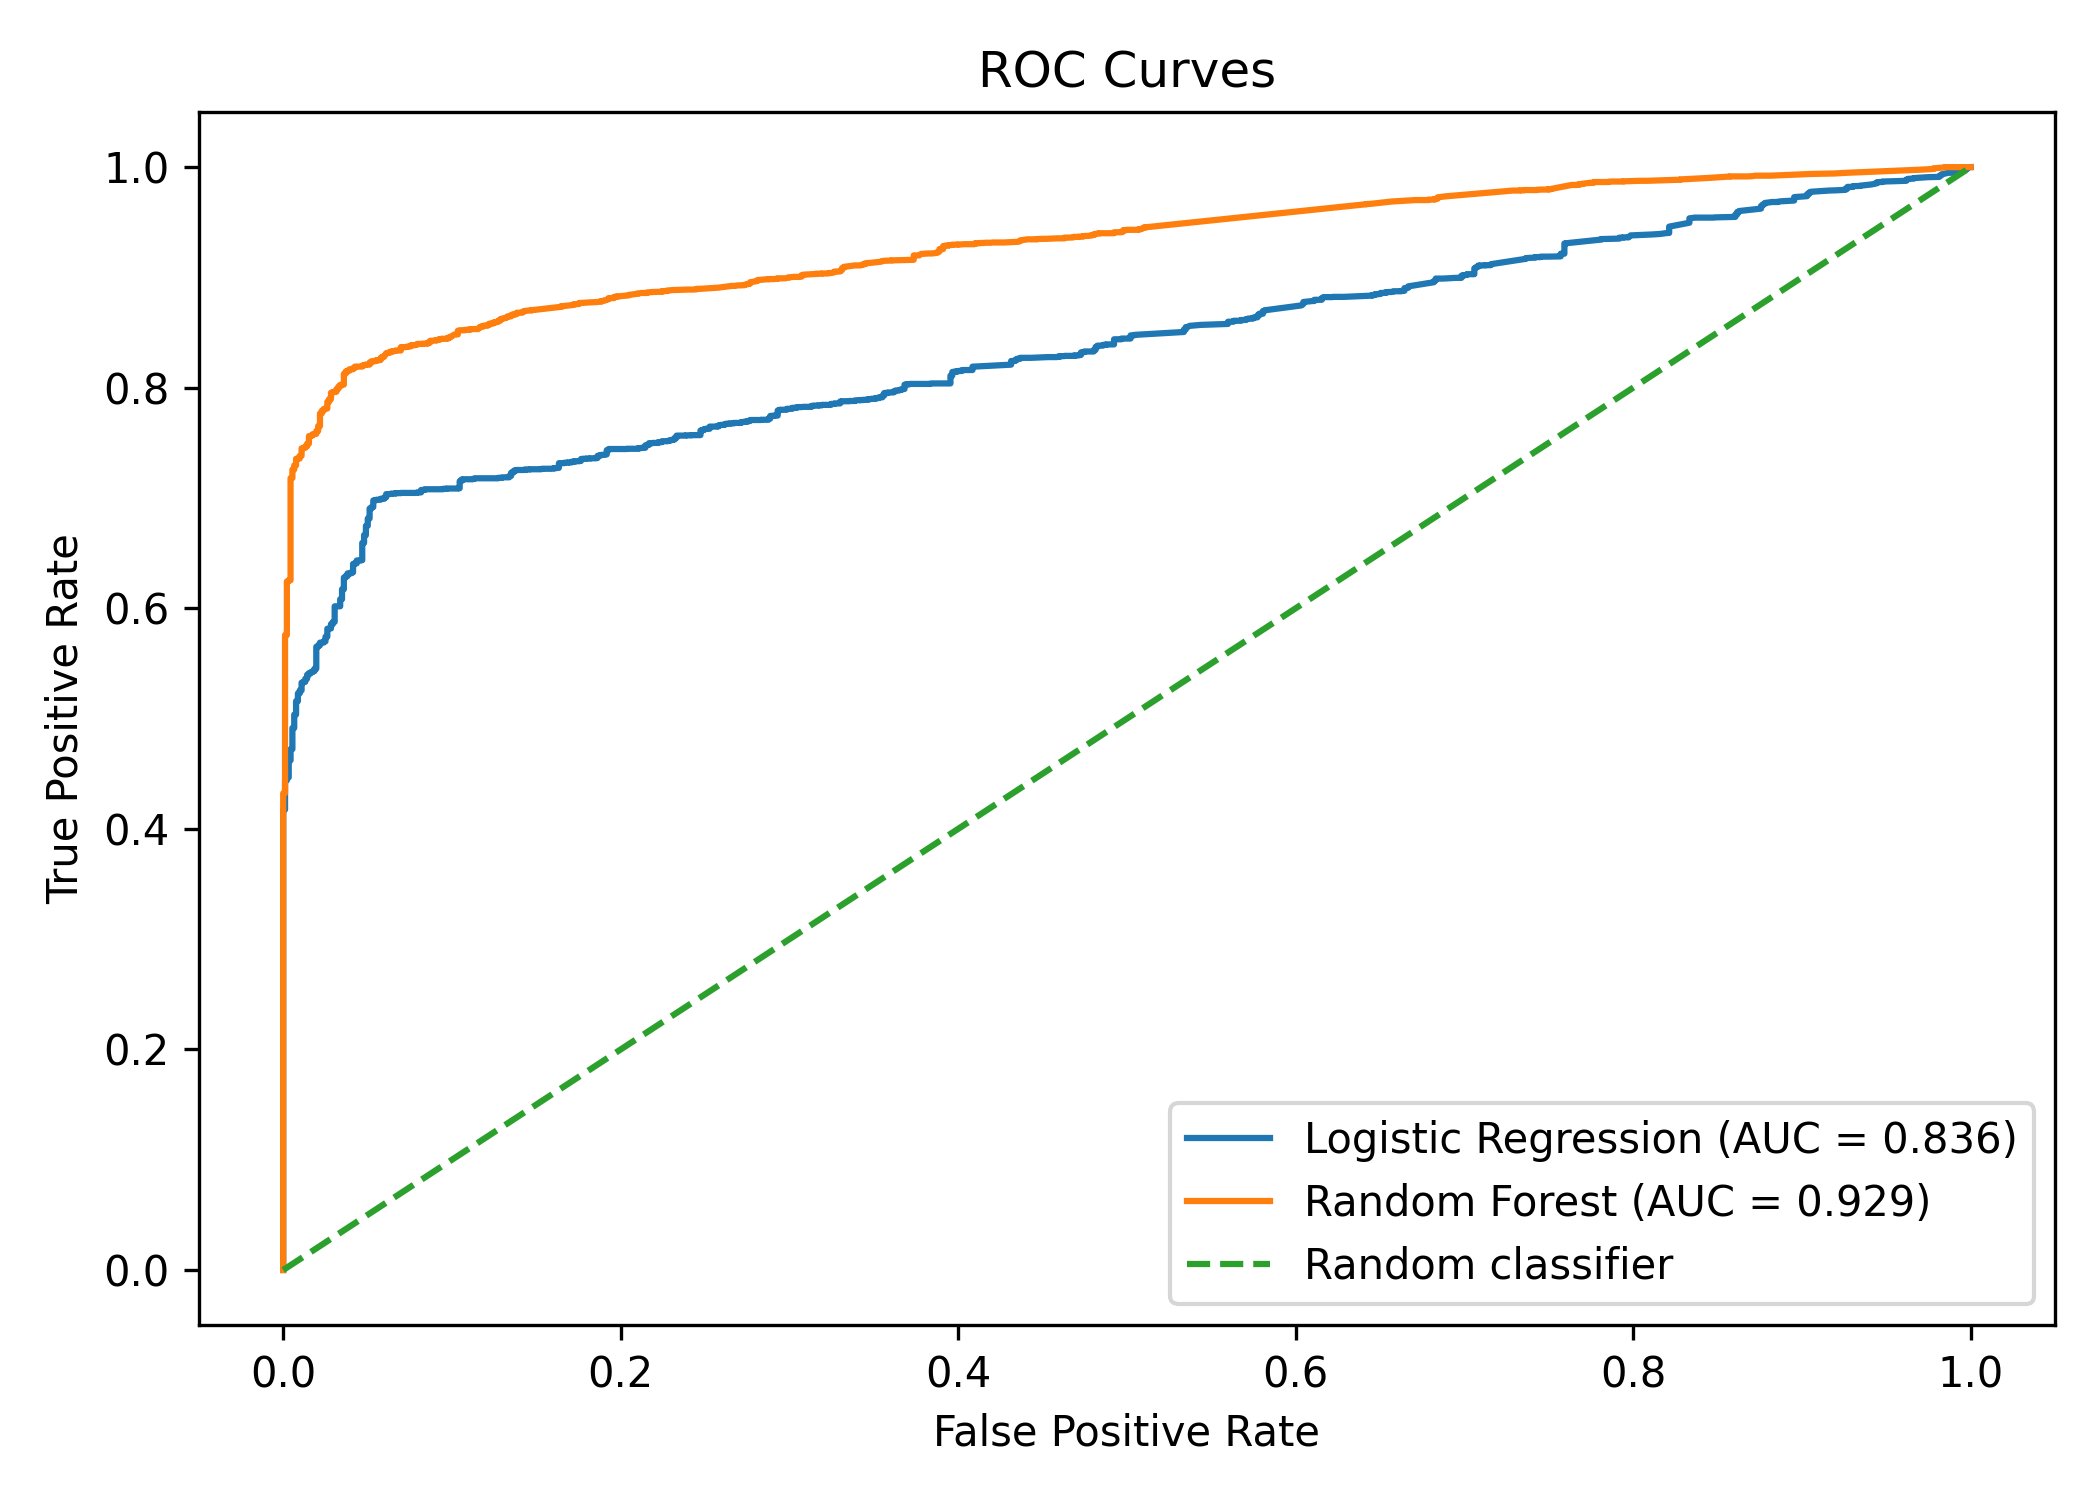

### Random Forest Confusion Matrix

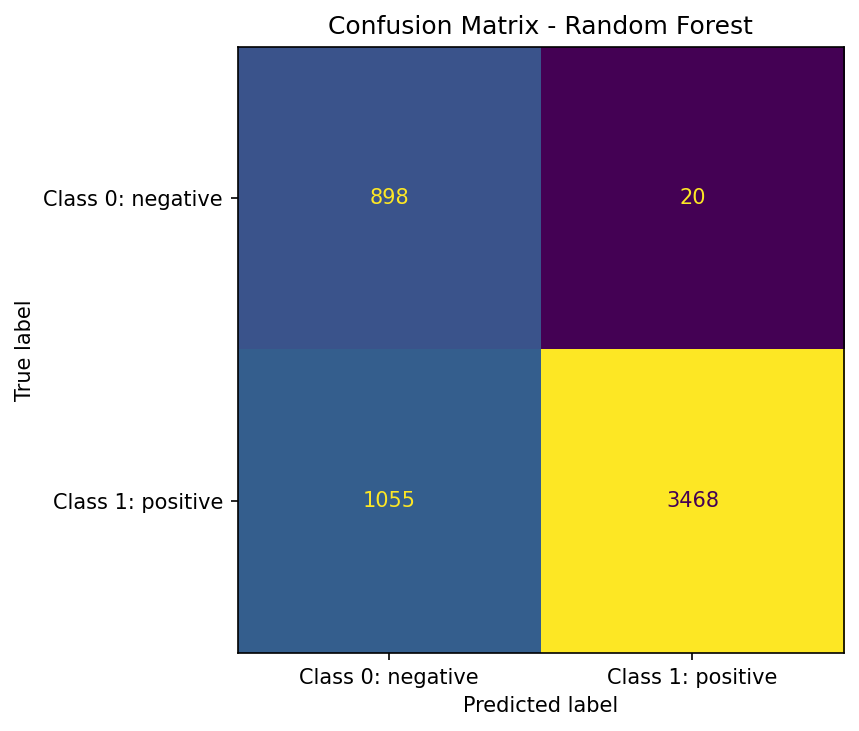

In [16]:
for figure_name in [
    "model_comparison",
    "roc_curves",
    "random_forest_confusion_matrix",
]:
    figure_path = evaluation_result.figure_paths.get(figure_name)

    if figure_path is not None and Path(figure_path).exists():
        display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))
        display(Image(filename=str(figure_path)))

## 13. Global SHAP explanations

The global SHAP summary and importance plots show which encoded features influence Random Forest predictions across the selected test sample.

The importance table ranks features by their mean absolute SHAP value. This measures influence magnitude, not whether a feature always pushes predictions toward the positive or negative class.


### Shap Summary

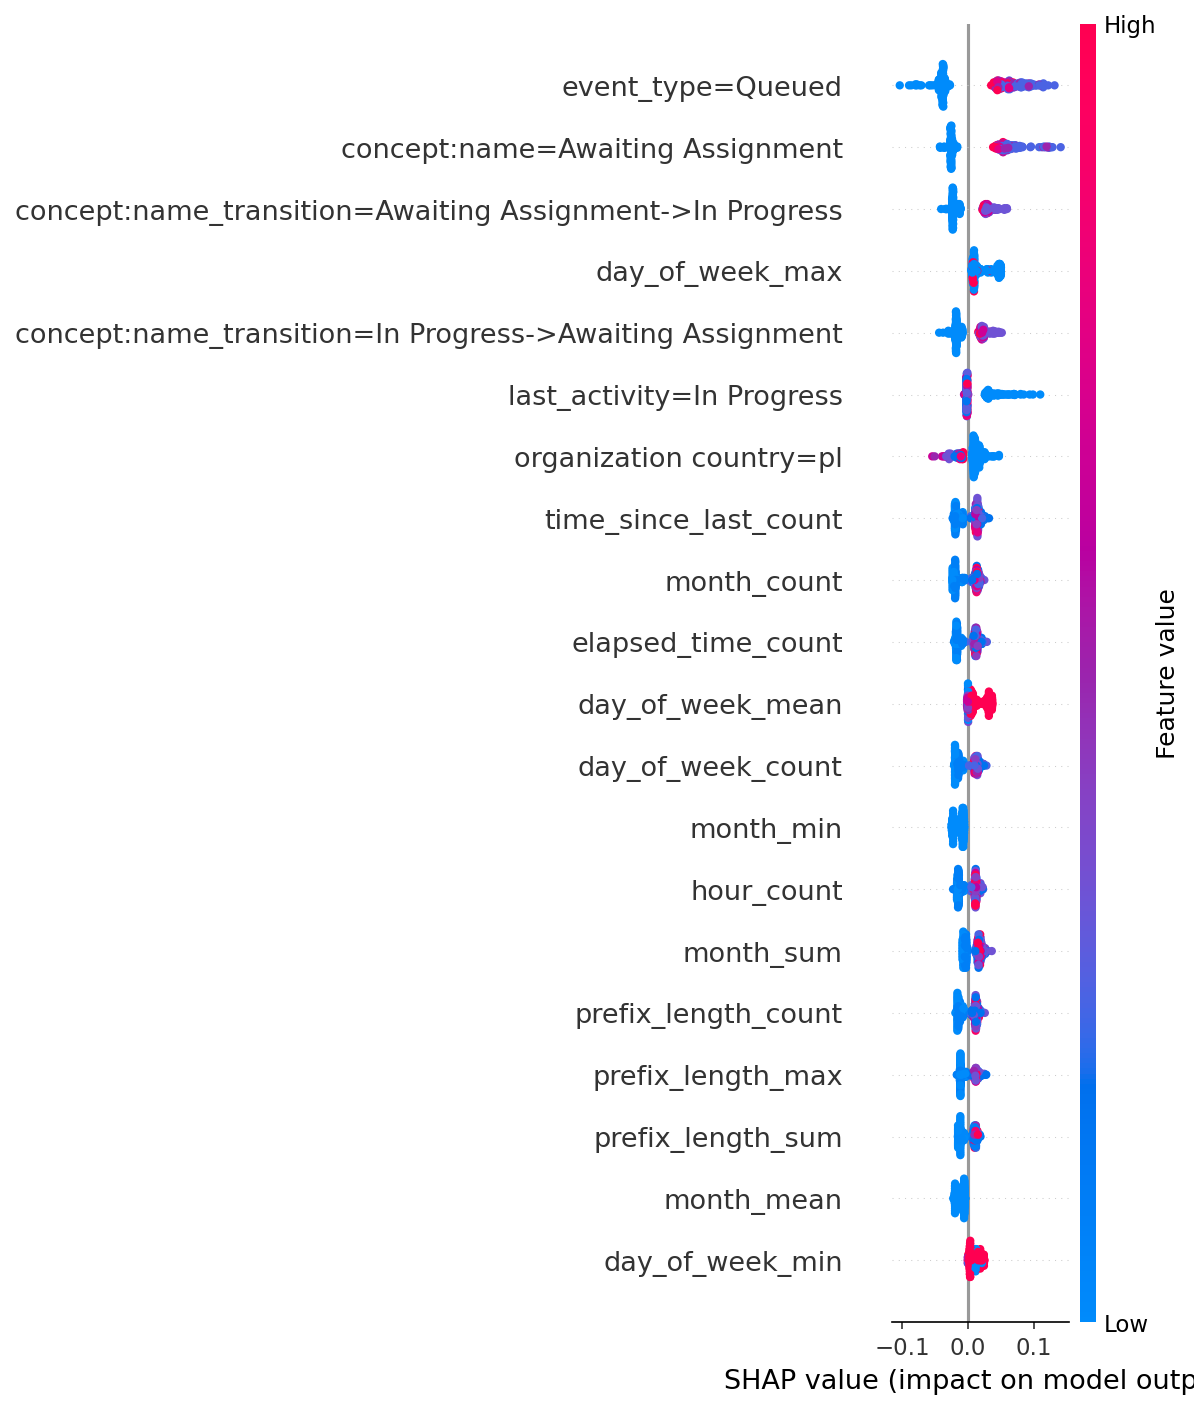

### Shap Importance

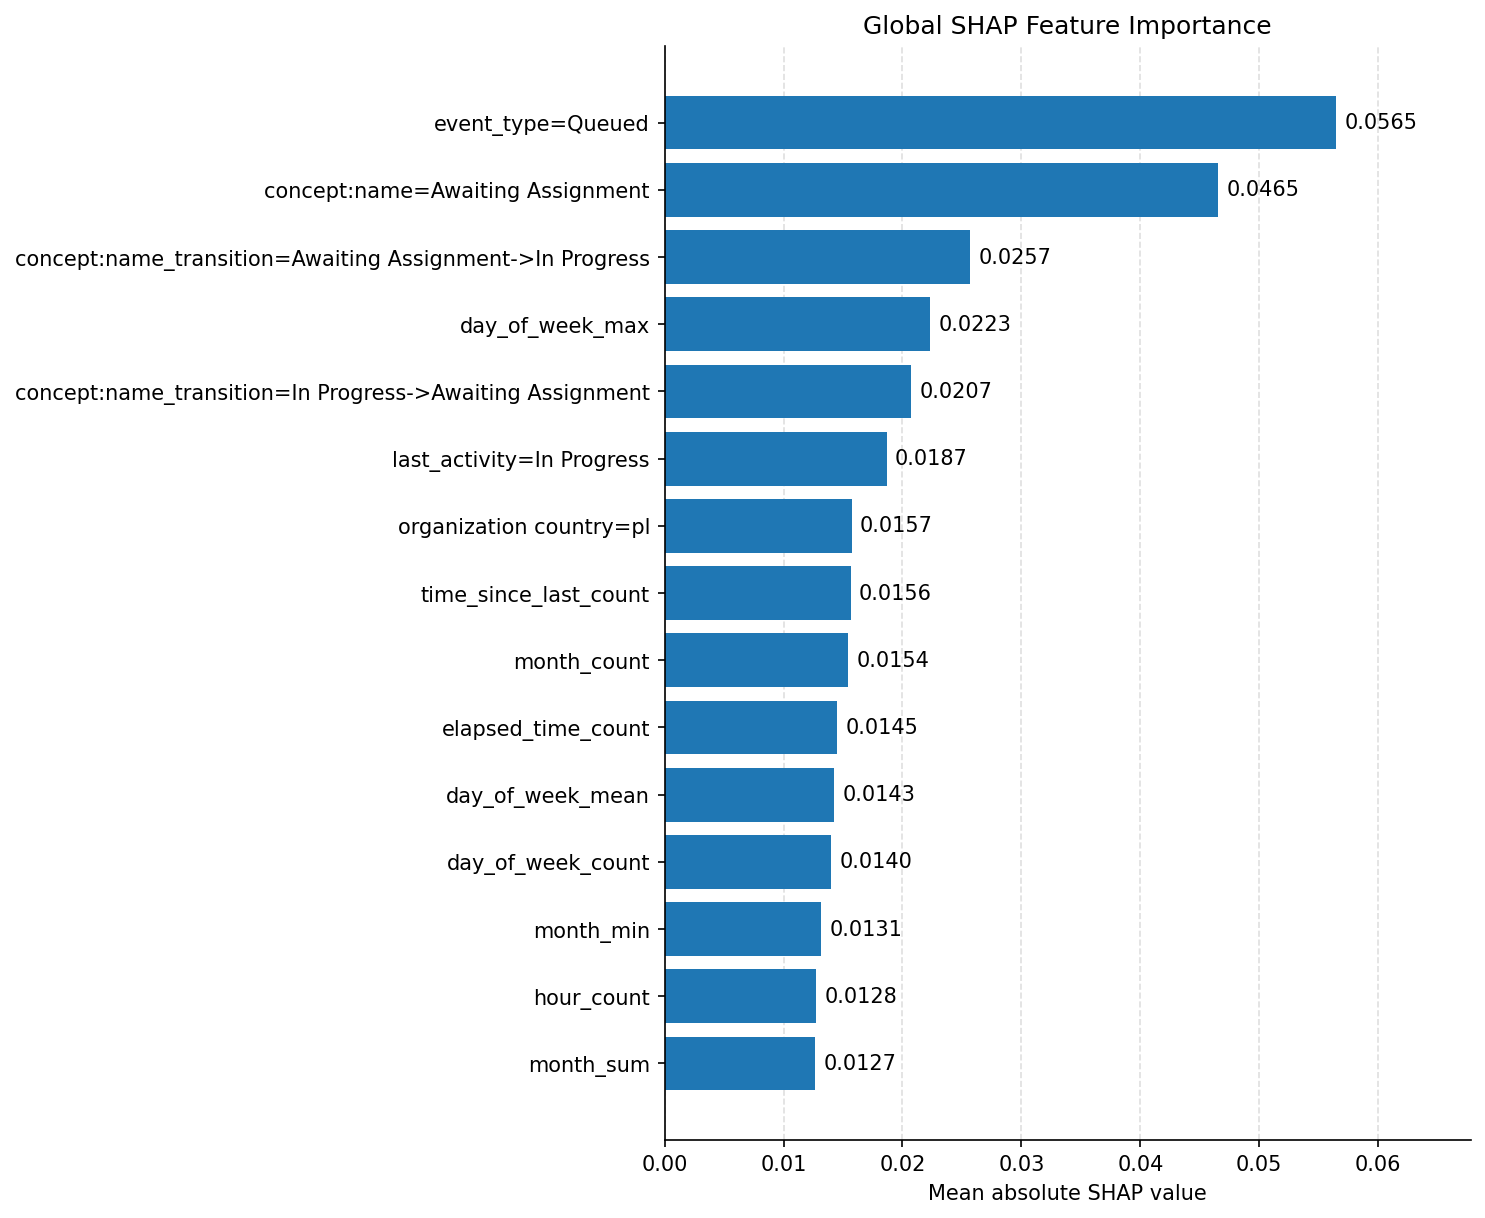

In [17]:
for figure_name in [
    "shap_summary",
    "shap_importance",
]:
    figure_path = evaluation_result.figure_paths.get(figure_name)

    if figure_path is not None and Path(figure_path).exists():
        display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))
        display(Image(filename=str(figure_path)))

In [18]:
if evaluation_result.shap_importance is not None:
    display(evaluation_result.shap_importance.head(15))
else:
    print("SHAP generation was disabled.")

,feature,mean_abs_shap
79,event_type=Queued,0.056481
82,concept:name=Awaiting Assignment,0.046534
99,concept:name_transition=Awaiting Assignment->I...,0.025717
196,day_of_week_max,0.022342
109,concept:name_transition=In Progress->Awaiting ...,0.020736
222,last_activity=In Progress,0.018674
47,organization country=pl,0.015728
186,time_since_last_count,0.015647
210,month_count,0.015410
180,elapsed_time_count,0.014488


## 14. Local SHAP explanations

Representative local explanations are selected automatically:

- one correctly predicted positive prefix;
- one correctly predicted negative prefix;
- one misclassified prefix, when such a case exists.

The metadata table links each explanation to its real test-prefix ID and prediction.


In [19]:
evaluation_result.local_explanations

,explanation_type,row_index,case_id,y_true,prediction,probability,figure_path
0,correct_positive,0,1-738190601_prefix_1,1,1,0.985416,/Users/so/Desktop/explainable-process-predicti...
1,correct_negative,297,1-739800638_prefix_1,0,0,0.190721,/Users/so/Desktop/explainable-process-predicti...
2,misclassified,153,1-739732277_prefix_1,1,0,0.288461,/Users/so/Desktop/explainable-process-predicti...


### Correct Positive

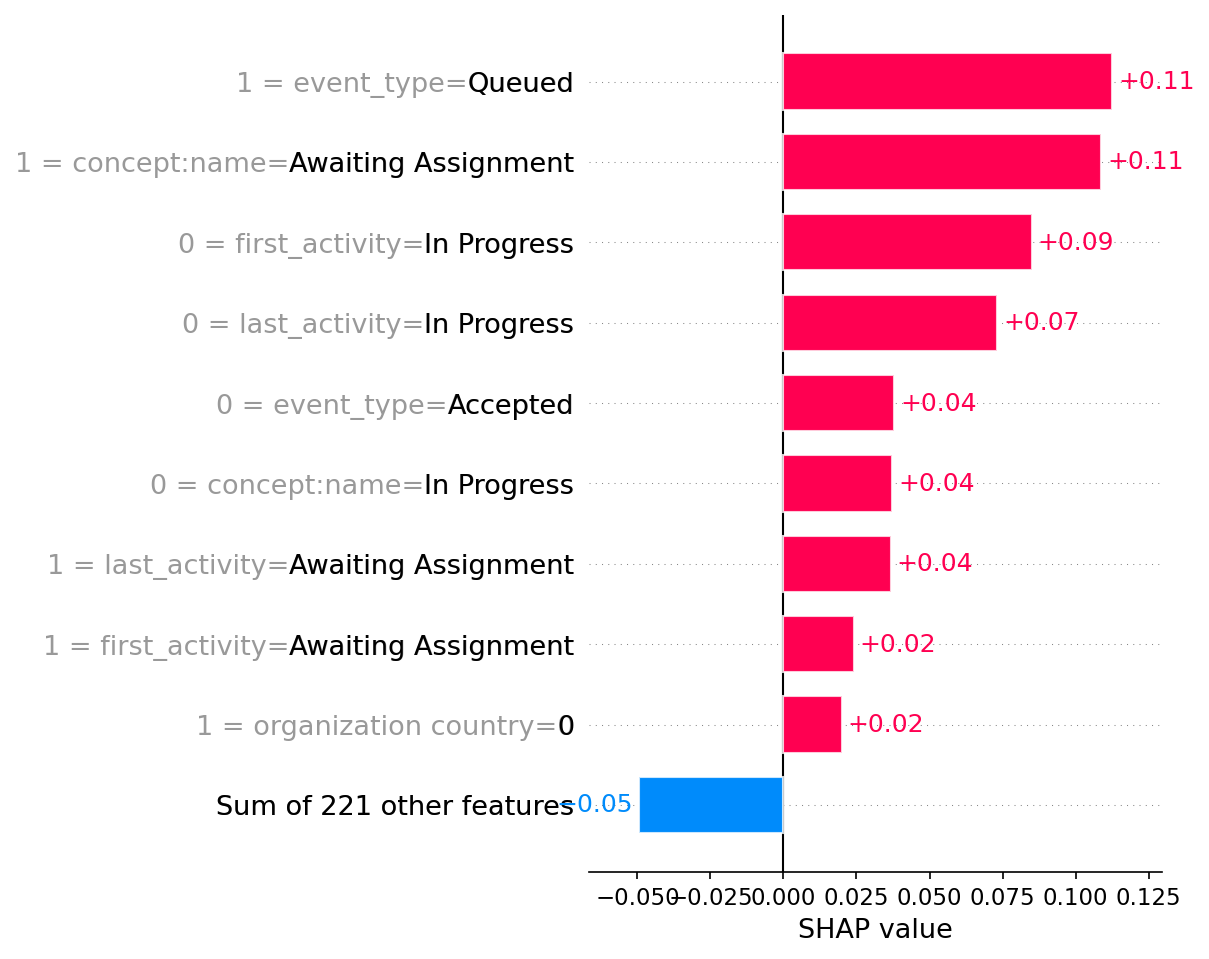

### Correct Negative

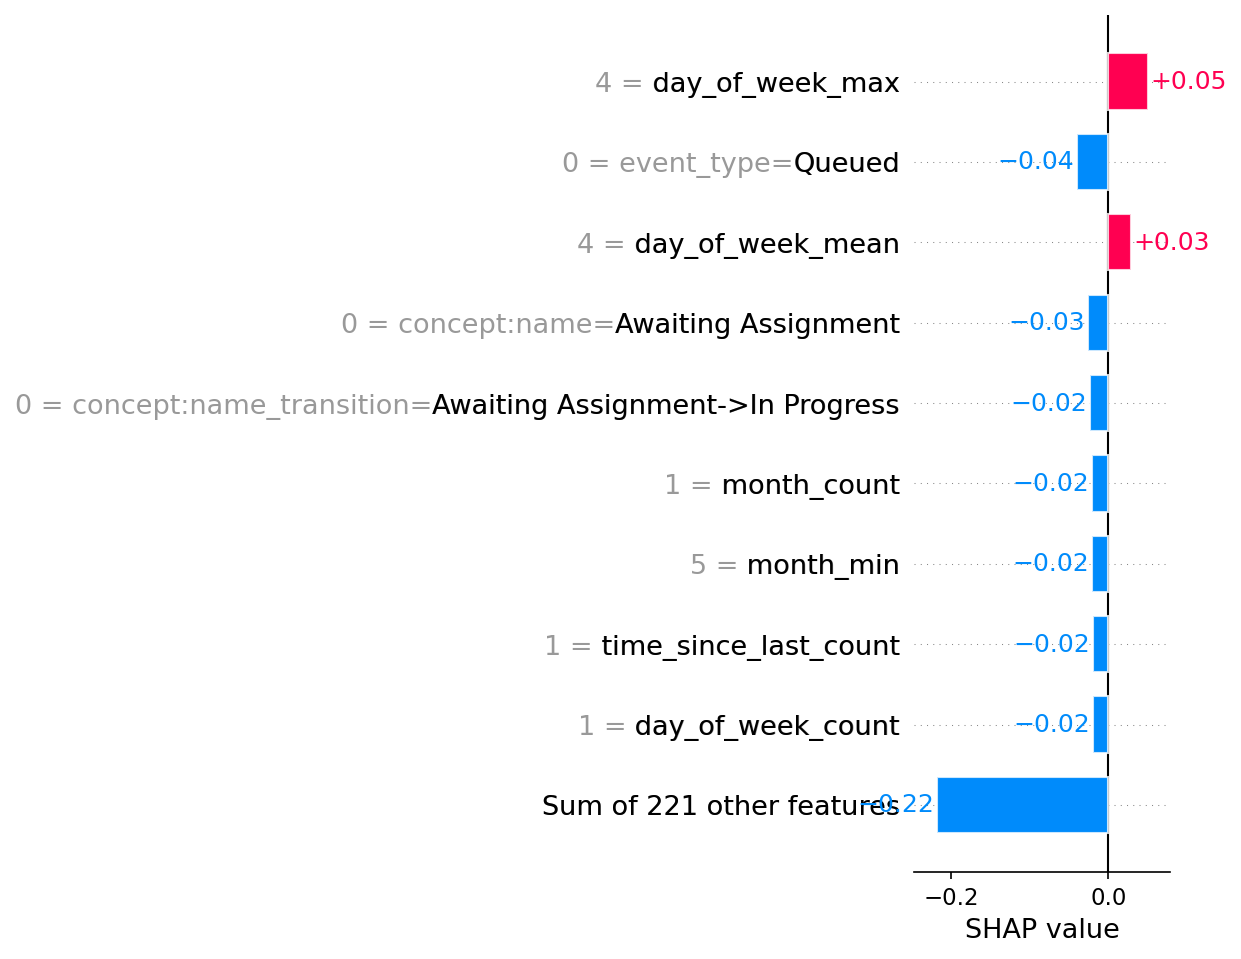

### Misclassified

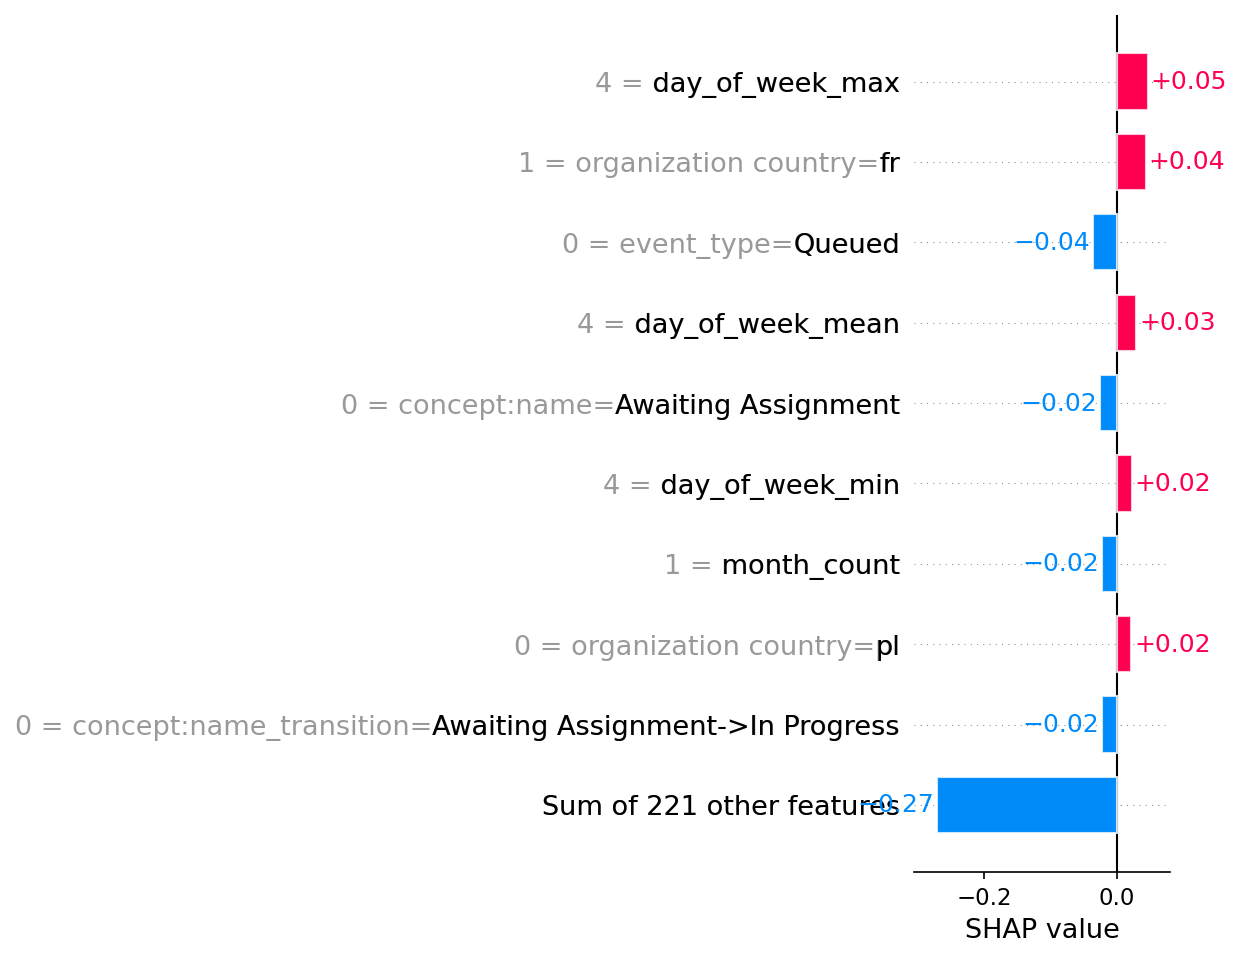

In [20]:
for explanation_type, figure_path in (
    evaluation_result.local_shap_paths.items()
):
    if Path(figure_path).exists():
        display(
            Markdown(
                f"### {explanation_type.replace('_', ' ').title()}"
            )
        )
        display(Image(filename=str(figure_path)))

## 15. Generated artifacts

The evaluation pipeline records the locations of all generated reports and figures. These files can be used directly in project documentation and the final report.


In [21]:
generated_reports = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in evaluation_result.report_paths.items()
    ]
)

generated_reports

,artifact,path
0,test_model_comparison,/Users/so/Desktop/explainable-process-predicti...
1,test_predictions,/Users/so/Desktop/explainable-process-predicti...
2,validation_model_comparison,/Users/so/Desktop/explainable-process-predicti...
3,random_forest_validation_results,/Users/so/Desktop/explainable-process-predicti...
4,shap_feature_importance,/Users/so/Desktop/explainable-process-predicti...
5,local_explanation_cases,/Users/so/Desktop/explainable-process-predicti...


In [22]:
generated_figures = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in evaluation_result.figure_paths.items()
    ]
)

generated_figures

,artifact,path
0,model_comparison,/Users/so/Desktop/explainable-process-predicti...
1,roc_curves,/Users/so/Desktop/explainable-process-predicti...
2,random_forest_confusion_matrix,/Users/so/Desktop/explainable-process-predicti...
3,shap_summary,/Users/so/Desktop/explainable-process-predicti...
4,shap_importance,/Users/so/Desktop/explainable-process-predicti...
5,shap_local_correct_positive,/Users/so/Desktop/explainable-process-predicti...
6,shap_local_correct_negative,/Users/so/Desktop/explainable-process-predicti...
7,shap_local_misclassified,/Users/so/Desktop/explainable-process-predicti...


## 16. Final pipeline checks

These checks verify the most important integration properties of the final notebook run.


In [23]:
expected_models = {
    "Majority baseline",
    "Logistic Regression",
    "Random Forest",
}

assert set(training_result.models) == expected_models
assert set(evaluation_result.test_comparison["model"]) == expected_models

expected_prediction_rows = (
    training_result.X_test.shape[0]
    * len(training_result.models)
)

assert len(evaluation_result.predictions) == expected_prediction_rows
assert evaluation_result.predictions["case_id"].notna().all()
assert evaluation_result.predictions["probability"].between(0, 1).all()
assert all(
    Path(path).exists()
    for path in evaluation_result.report_paths.values()
)
assert all(
    Path(path).exists()
    for path in evaluation_result.figure_paths.values()
)

print("All final pipeline checks passed.")

All final pipeline checks passed.


## Summary

This notebook demonstrates a complete prefix-level outcome-prediction workflow without implementing the workflow inside notebook cells.

The final implementation:

- defines outcomes from final lifecycle transitions;
- splits original cases temporally before prefix generation;
- keeps prefixes from the same original case in one data split;
- aligns train, validation, and test feature spaces;
- compares a majority baseline, Logistic Regression, and Random Forest;
- selects Random Forest hyperparameters using validation F1;
- evaluates all models once on the held-out test set;
- exports structured predictions with real prefix IDs;
- generates model-performance visualizations;
- provides global and local SHAP explanations;
- saves all reports and figures reproducibly.

The same underlying implementation can be executed either through this notebook or through:

```bash
python scripts/run_pipeline.py \
    --data data/raw/BPI_Challenge_2013_incidents/BPI_Challenge_2013_incidents.xes \
    --output-dir outputs
```

This removes the earlier dependency on running notebooks in a particular order and makes the project workflow reusable, testable, and reproducible.
